# **Python For Data Analystics - Module end assignment**

# **Social Media Engagement Analytics**

### **Task 1 : Data Import and Setup**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("social_media_engagement_5000.csv")

In [8]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [9]:
#Convert date column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'],dayfirst=True)

In [10]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


### **Task 2 - Data Cleaning**

In [11]:
#Cleaning Missing Data
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [12]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [13]:
#Filling the Numerical column with mean
df['comments'].fillna(df['comments'].mean(), inplace=True)
df['likes'].fillna(df['likes'].mean(), inplace=True)
df['shares'].fillna(df['shares'].mean(), inplace=True)
df['age'].fillna(df['age'].mean(), inplace=True)

/tmp/ipykernel_499/3569084383.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['comments'].fillna(df['comments'].mean(), inplace=True)
/tmp/ipykernel_499/3569084383.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [14]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.00000,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.00000,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.00000,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.00000,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.00000,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [15]:
#Filling Categorical columns
df['gender']=df['gender'].fillna("Unknown")
df['sentiment']=df['sentiment'].fillna("Unknown")


In [16]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.00000,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.00000,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.00000,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.00000,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.00000,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [17]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [18]:
#Identify Duplicates
df.duplicated("user_id").sum()

np.int64(138)

In [19]:
df.drop_duplicates("user_id",inplace=True) # Removed Duplicates

In [20]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.00000,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.00000,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.00000,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.00000,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.00000,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


### **Data Formating**

In [21]:
#data type formatting
df['comments'] = df['comments'].astype(int)
df['likes'] = df['likes'].astype(int)
df['shares'] = df['shares'].astype(int)
df['age'] = df['age'].astype(int)

In [22]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [23]:
#Extract Hashtags count
df['hashtags']=df['hashtags'].str.split("#")
df['hashtags_count']=df['hashtags'].apply(lambda x: len(x)-1)

In [24]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtags_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,"[, foodie , travel , love]",0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,"[, fitness]",0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,"[, foodie]",0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,"[, music , foodie , fun]",0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,"[, travel]",2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,"[, travel , fun]",0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,"[, foodie , reels]",0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,7466,23680,2023-04-06,483550,False,desktop,positive,"[, lifestyle , tech]",0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,"[, reels , love , fitness]",0.223518,3


In [25]:
# Cleaning Sentiment by title()
df['sentiment']=df['sentiment'].str.title()

In [26]:
# Cleaning Columns
df.columns=df.columns.str.replace('_',' ')

In [27]:
df

,user id,age,gender,country,post id,post type,post category,likes,comments,shares,watch time sec,impression count,posted at,follower count,is verified,device type,sentiment,hashtags,engagement rate,hashtags count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,Negative,"[, foodie , travel , love]",0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,Negative,"[, fitness]",0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,Positive,"[, foodie]",0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,Negative,"[, music , foodie , fun]",0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,Negative,"[, travel]",2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,Positive,"[, travel , fun]",0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,Negative,"[, foodie , reels]",0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,7466,23680,2023-04-06,483550,False,desktop,Positive,"[, lifestyle , tech]",0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,Positive,"[, reels , love , fitness]",0.223518,3


### **Task 3 - Data Exploration Using Pandas**

In [28]:
df.head()

,user id,age,gender,country,post id,post type,post category,likes,comments,shares,watch time sec,impression count,posted at,follower count,is verified,device type,sentiment,hashtags,engagement rate,hashtags count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,Negative,"[, foodie , travel , love]",0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,Negative,"[, fitness]",0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,Positive,"[, foodie]",0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,Negative,"[, music , foodie , fun]",0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,Negative,"[, travel]",2.777372,1


In [29]:
df.tail()

,user id,age,gender,country,post id,post type,post category,likes,comments,shares,watch time sec,impression count,posted at,follower count,is verified,device type,sentiment,hashtags,engagement rate,hashtags count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,Positive,"[, travel , fun]",0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,Negative,"[, foodie , reels]",0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,7466,23680,2023-04-06,483550,False,desktop,Positive,"[, lifestyle , tech]",0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,Positive,"[, reels , love , fitness]",0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,Neutral,"[, foodie , lifestyle , fashion]",1.203527,3


In [30]:
df.shape

(4862, 20)

In [31]:
df.columns

Index(['user id', 'age', 'gender', 'country', 'post id', 'post type',
       'post category', 'likes', 'comments', 'shares', 'watch time sec',
       'impression count', 'posted at', 'follower count', 'is verified',
       'device type', 'sentiment', 'hashtags', 'engagement rate',
       'hashtags count'],
      dtype='object')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4862 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user id           4862 non-null   int64         
 1   age               4862 non-null   int64         
 2   gender            4862 non-null   object        
 3   country           4862 non-null   object        
 4   post id           4862 non-null   int64         
 5   post type         4862 non-null   object        
 6   post category     4862 non-null   object        
 7   likes             4862 non-null   int64         
 8   comments          4862 non-null   int64         
 9   shares            4862 non-null   int64         
 10  watch time sec    4862 non-null   int64         
 11  impression count  4862 non-null   int64         
 12  posted at         4862 non-null   datetime64[ns]
 13  follower count    4862 non-null   int64         
 14  is verified       4862 non-nu

In [33]:
df.dtypes

,0
user id,int64
age,int64
gender,object
country,object
post id,int64
post type,object
post category,object
likes,int64
comments,int64
shares,int64


In [34]:
df.describe()

,user id,age,post id,likes,comments,shares,watch time sec,impression count,posted at,follower count,engagement rate,hashtags count
count,4862.000000,4862.000000,4862.000000,4862.000000,4862.000000,4862.000000,4862.000000,4862.000000,4862,4862.000000,4862.000000,4862.000000
mean,54666.067462,38.469148,548814.391608,10099.653846,1502.864253,1001.341835,4016.287536,50037.794118,2022-12-27 14:17:43.266145536,394125.555533,0.972642,1.997121
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.007420,1.000000
25%,32422.750000,26.000000,324873.750000,5208.250000,791.000000,510.000000,2015.500000,25074.750000,2022-07-02 00:00:00,194741.000000,0.145443,1.000000
50%,54458.500000,38.000000,549198.500000,10107.000000,1502.000000,1002.000000,4054.000000,49914.500000,2022-12-26 00:00:00,389665.500000,0.253180,2.000000
75%,77347.500000,51.000000,771088.250000,14920.250000,2234.750000,1476.750000,6019.750000,74755.250000,2023-06-25 18:00:00,590151.000000,0.504274,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26128.624111,14.703438,259801.040833,5707.260481,856.658752,570.182770,2309.115545,28855.386340,NaN,231023.848864,5.387479,0.813378


In [35]:
df['gender'].value_counts()

,count
gender,
Male,1655
Other,1544
Female,1520
Unknown,143


In [36]:
df['user id'].unique()

array([25795, 10860, 86820, ..., 67021, 29800, 73400])

In [37]:
df['user id'].nunique() # Count of unique data

4862

In [38]:
#Corelation Matrix for numerical columns
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

print(corr_matrix)

                   user id       age   post id     likes  comments    shares  \
user id           1.000000 -0.005738  0.019069  0.020702 -0.032726  0.013499   
age              -0.005738  1.000000 -0.013234 -0.036319 -0.008740  0.011794   
post id           0.019069 -0.013234  1.000000  0.010910 -0.011393  0.006291   
likes             0.020702 -0.036319  0.010910  1.000000 -0.018658  0.005664   
comments         -0.032726 -0.008740 -0.011393 -0.018658  1.000000  0.004993   
shares            0.013499  0.011794  0.006291  0.005664  0.004993  1.000000   
watch time sec   -0.016369  0.006016  0.012872  0.006491 -0.015882  0.015676   
impression count  0.012463  0.019623 -0.008348  0.009610 -0.009782 -0.003400   
follower count    0.007974 -0.026021 -0.001184 -0.021231 -0.012223 -0.007621   
engagement rate  -0.003545  0.007561  0.011091  0.094760 -0.000232  0.021105   
hashtags count   -0.011184  0.005772  0.000072 -0.003761 -0.014634  0.013307   

                  watch time sec  impre

In [39]:
# Average Likes by post type
avg_likes_by_post_type = df.groupby('post type')['likes'].mean()
print(avg_likes_by_post_type)

post type
image    10037.569547
reel      9984.729469
text     10156.991736
video    10224.164017
Name: likes, dtype: float64


In [40]:
#Impressions by country
impressions_by_country = df.groupby('country')['impression count'].sum()
print(impressions_by_country)

country
Australia    23473069
Brazil       24048512
Canada       24160984
France       25094015
Germany      23194249
India        27542332
Japan        22719857
UAE          23763289
UK           24409278
USA          24878170
Name: impression count, dtype: int64


In [41]:
df

,user id,age,gender,country,post id,post type,post category,likes,comments,shares,watch time sec,impression count,posted at,follower count,is verified,device type,sentiment,hashtags,engagement rate,hashtags count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,Negative,"[, foodie , travel , love]",0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,Negative,"[, fitness]",0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,Positive,"[, foodie]",0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,Negative,"[, music , foodie , fun]",0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,Negative,"[, travel]",2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,Positive,"[, travel , fun]",0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,Negative,"[, foodie , reels]",0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,7466,23680,2023-04-06,483550,False,desktop,Positive,"[, lifestyle , tech]",0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,Positive,"[, reels , love , fitness]",0.223518,3


### **Task 4 - Data Wrangling**

In [42]:
# Engagemennt score
df['engagement score'] = (
    df['likes'] +
    df['comments'] * 2 +
    df['shares'] * 3
)

In [43]:
df

,user id,age,gender,country,post id,post type,post category,likes,comments,shares,...,impression count,posted at,follower count,is verified,device type,sentiment,hashtags,engagement rate,hashtags count,engagement score
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,...,44650,2022-12-17,81734,False,mobile,Negative,"[, foodie , travel , love]",0.190862,3,11190
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,...,80216,2023-06-02,5963,False,mobile,Negative,"[, fitness]",0.201493,1,22383
2,86820,32,Female,UK,109864,text,food,4862,344,955,...,44858,2023-05-07,501783,False,tablet,Positive,"[, foodie]",0.137345,1,8415
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,...,70455,2023-02-12,480212,False,mobile,Negative,"[, music , foodie , fun]",0.106195,3,10663
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,...,6019,2023-05-23,383936,False,mobile,Negative,"[, travel]",2.777372,1,22052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,...,42977,2022-06-25,646147,False,mobile,Positive,"[, travel , fun]",0.466761,2,25747
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,...,34196,2022-11-18,584603,False,desktop,Negative,"[, foodie , reels]",0.621155,2,27141
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,...,23680,2023-04-06,483550,False,desktop,Positive,"[, lifestyle , tech]",0.679688,2,16992
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,...,89013,2022-05-16,183295,False,tablet,Positive,"[, reels , love , fitness]",0.223518,3,24611


In [44]:
#Group by Post_type,country and sentiment
Summarise=df.groupby(['post type','country','sentiment']).describe()
print(Summarise)

                              user id                                   \
                                count          mean      min       25%   
post type country   sentiment                                            
image     Australia Negative     19.0  49453.894737  12368.0  27516.00   
                    Neutral      41.0  53458.292683  12454.0  24924.00   
                    Positive     56.0  61357.053571  10235.0  39164.00   
                    Unknown       7.0  83759.142857  47080.0  74228.50   
          Brazil    Negative     20.0  50519.250000  11605.0  22263.75   
...                               ...           ...      ...       ...   
video     UK        Unknown       2.0  54378.000000  24671.0  39524.50   
          USA       Negative     20.0  50534.250000  17314.0  26657.00   
                    Neutral      39.0  55418.512821  11700.0  28962.00   
                    Positive     52.0  58089.192308  11813.0  37525.50   
                    Unknown       2.0 

## **Task 5 - Statistical Analysis**

In [45]:
#compute descriptive statistics
# List of numerical columns
cols = ['likes', 'comments', 'shares',
        'engagement rate','watch time sec','follower count']

# Mean
print("Mean:")
print(df[cols].mean())

# Median
print("\nMedian:")
print(df[cols].median())

# Mode
print("\nMode:")
print(df[cols].mode().iloc[0])

# Standard Deviation
print("\nStandard Deviation:")
print(df[cols].std())

# Variance
print("\nVariance:")
print(df[cols].var())

# Percentiles
print("\nPercentiles:")
print(df[cols].quantile([0.25, 0.50, 0.75, 0.90, 0.95]))


Mean:
likes               10099.653846
comments             1502.864253
shares               1001.341835
engagement rate         0.972642
watch time sec       4016.287536
follower count     394125.555533
dtype: float64

Median:
likes               10107.00000
comments             1502.00000
shares               1002.00000
engagement rate         0.25318
watch time sec       4054.00000
follower count     389665.50000
dtype: float64

Mode:
likes               10107.00000
comments             1502.00000
shares               1002.00000
engagement rate         0.00742
watch time sec        916.00000
follower count     497502.00000
Name: 0, dtype: float64

Standard Deviation:
likes                5707.260481
comments              856.658752
shares                570.182770
engagement rate         5.387479
watch time sec       2309.115545
follower count     231023.848864
dtype: float64

Variance:
likes              3.257282e+07
comments           7.338642e+05
shares             3.251084e+05
e

### **Task 6 - Data Visualisation**

### **Matplotlib**

In [46]:
df

,user id,age,gender,country,post id,post type,post category,likes,comments,shares,...,impression count,posted at,follower count,is verified,device type,sentiment,hashtags,engagement rate,hashtags count,engagement score
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,...,44650,2022-12-17,81734,False,mobile,Negative,"[, foodie , travel , love]",0.190862,3,11190
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,...,80216,2023-06-02,5963,False,mobile,Negative,"[, fitness]",0.201493,1,22383
2,86820,32,Female,UK,109864,text,food,4862,344,955,...,44858,2023-05-07,501783,False,tablet,Positive,"[, foodie]",0.137345,1,8415
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,...,70455,2023-02-12,480212,False,mobile,Negative,"[, music , foodie , fun]",0.106195,3,10663
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,...,6019,2023-05-23,383936,False,mobile,Negative,"[, travel]",2.777372,1,22052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,...,42977,2022-06-25,646147,False,mobile,Positive,"[, travel , fun]",0.466761,2,25747
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,...,34196,2022-11-18,584603,False,desktop,Negative,"[, foodie , reels]",0.621155,2,27141
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,...,23680,2023-04-06,483550,False,desktop,Positive,"[, lifestyle , tech]",0.679688,2,16992
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,...,89013,2022-05-16,183295,False,tablet,Positive,"[, reels , love , fitness]",0.223518,3,24611


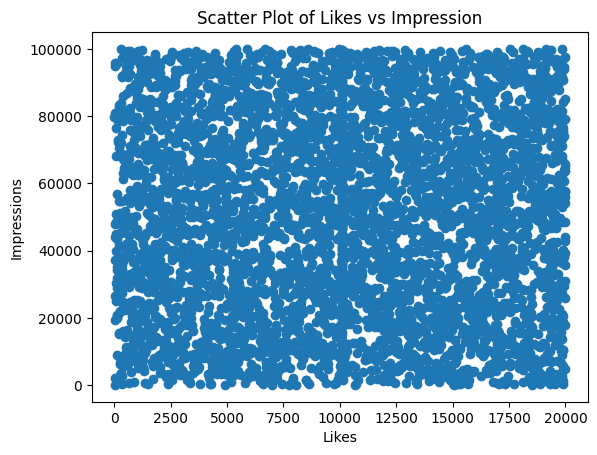

In [47]:
#scatter plot
plt.scatter(df['likes'], df['impression count'])
plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.title('Scatter Plot of Likes vs Impression')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

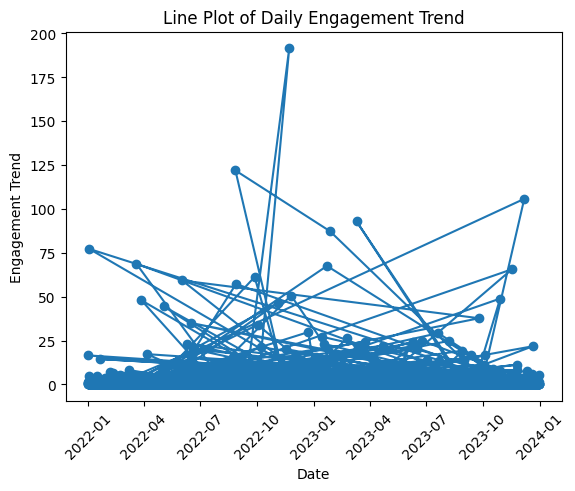

In [48]:
#Line plot
plt.plot(df['posted at'], df['engagement rate'], marker='o')
plt.xlabel('Date')
plt.ylabel('Engagement Trend')
plt.title('Line Plot of Daily Engagement Trend')
plt.xticks(rotation=45)
plt.show


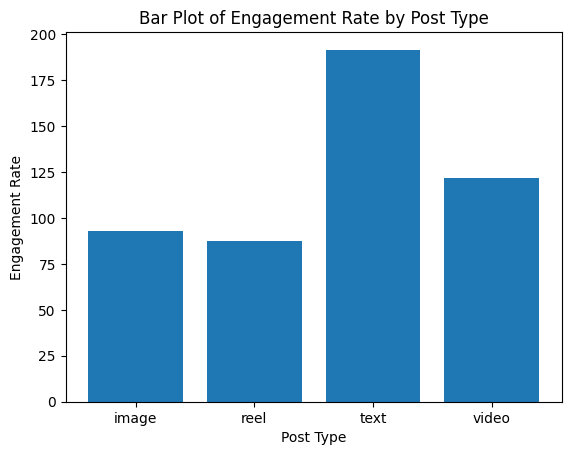

In [78]:
#Bar Plot
plt.bar(df['post type'], df['engagement rate'])
plt.xlabel('Post Type')
plt.ylabel('Engagement Rate')
plt.title('Bar Plot of Engagement Rate by Post Type')
plt.show()

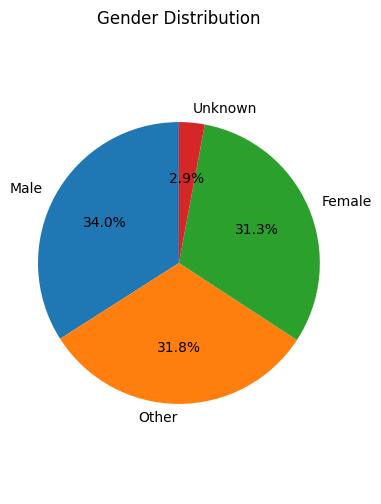

In [50]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(4, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

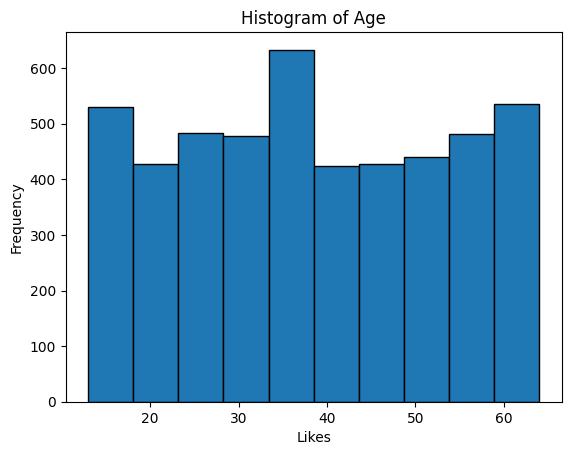

In [51]:
#Histogram
plt.hist(df['age'], bins=10, edgecolor='black')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.show()
#

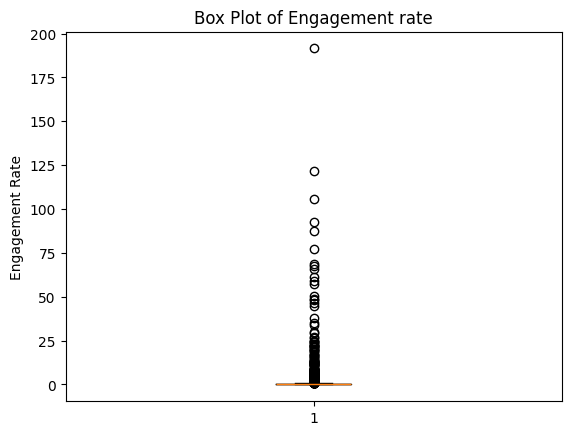

In [52]:
# Box plot
plt.boxplot(df['engagement rate'])
plt.ylabel('Engagement Rate')
plt.title('Box Plot of Engagement rate')
plt.show()

### **Seaborn**

<function matplotlib.pyplot.show(close=None, block=None)>

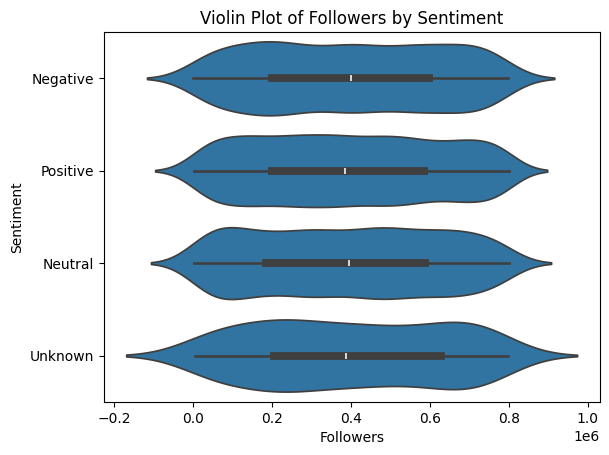

In [53]:
#Violin plot
sns.violinplot(x='follower count', y='sentiment', data=df)
plt.xlabel('Followers')
plt.ylabel('Sentiment')
plt.title('Violin Plot of Followers by Sentiment')
plt.show


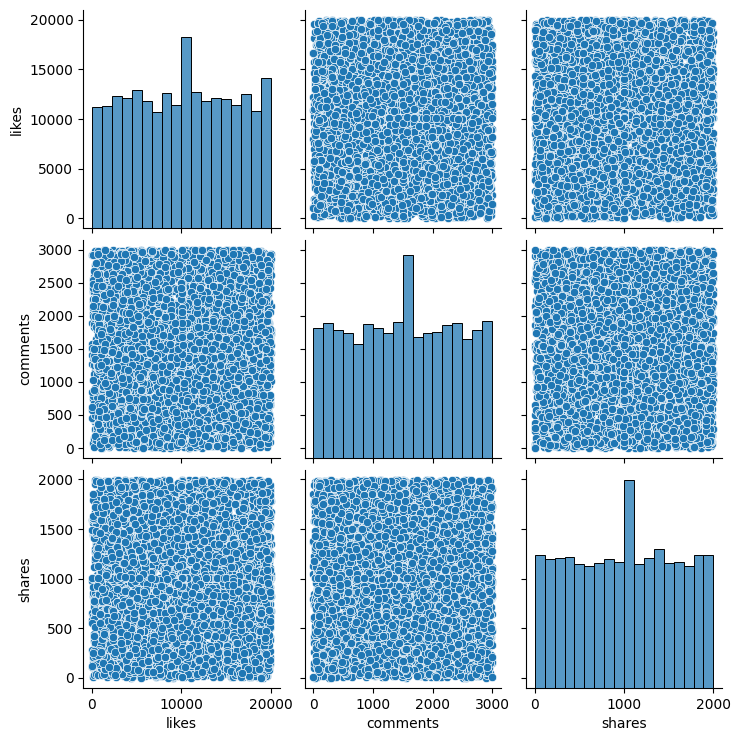

In [54]:
# Pair plot
sns.pairplot(df[['likes', 'comments', 'shares']])
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

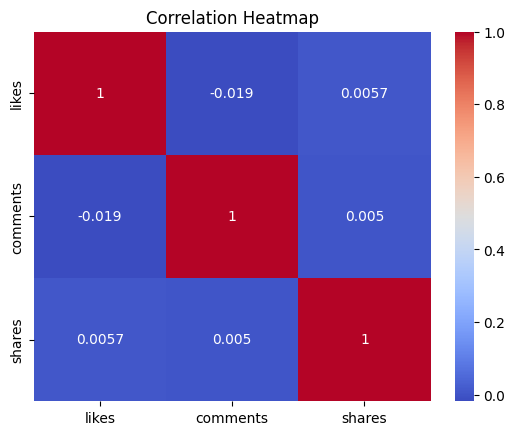

In [55]:
# Heat Map
correlation_matrix = df[['likes', 'comments', 'shares']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

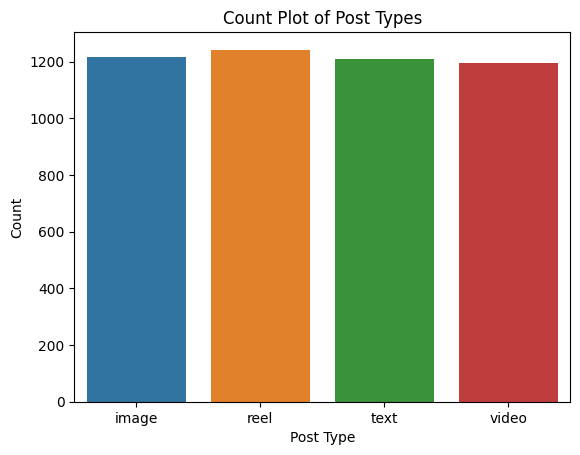

In [56]:
# Count plot
sns.countplot(x='post type', hue='post type', data=df)
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.title('Count Plot of Post Types')
plt.show()

## **Final Insights**

### **Content Performance**

In [57]:
#Which post type has highest engagement rate
High_engagement_rate_by_post_type = df.groupby('post type')['engagement rate'].max()
print(High_engagement_rate_by_post_type)

post type
image     92.828829
reel      87.266094
text     191.504348
video    121.931973
Name: engagement rate, dtype: float64


In [58]:
#Best-performing content category
best_performing_content_category = df['post category'].max()
print(best_performing_content_category)


travel


In [59]:
#Which countries have the highest average engagement rate
highest_average_engagement_rate_by_country = df.groupby('country')['engagement rate'].mean()
print(highest_average_engagement_rate_by_country)

country
Australia    1.318358
Brazil       1.574824
Canada       0.904511
France       1.161718
Germany      0.765602
India        0.661362
Japan        0.781781
UAE          1.113851
UK           0.866834
USA          0.584566
Name: engagement rate, dtype: float64


### **User Trends**

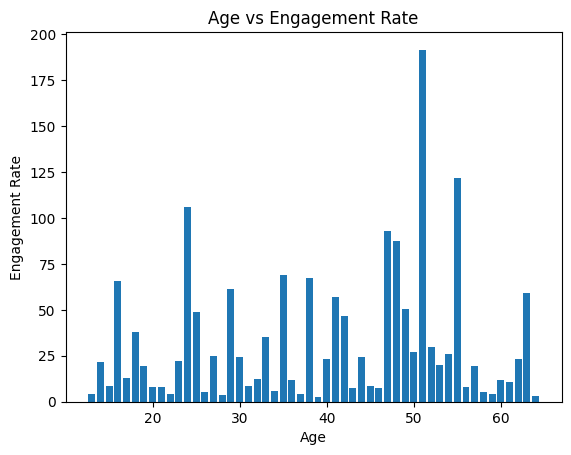

In [66]:
#How age affects engagement
plt.bar(df['age'], df['engagement rate'])
plt.xlabel('Age')
plt.ylabel('Engagement Rate')
plt.title('Age vs Engagement Rate')
plt.show()

In [63]:
#Performance difference for verified accounts
verified_accounts_performance = df.groupby('is verified')['engagement rate'].mean()
print(verified_accounts_performance)

is verified
False    0.962725
True     1.064883
Name: engagement rate, dtype: float64


## **Behavioural Insights**

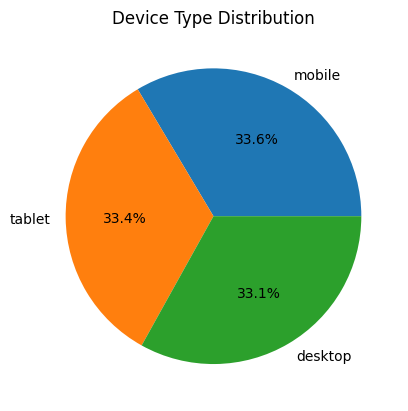

In [73]:
#Device type impact on watch time
plt.pie(df['device type'].value_counts(), labels=df['device type'].value_counts().index, autopct='%1.1f%%')
plt.title('Device Type Distribution')
plt.show()

## **Sentimental Analysis**

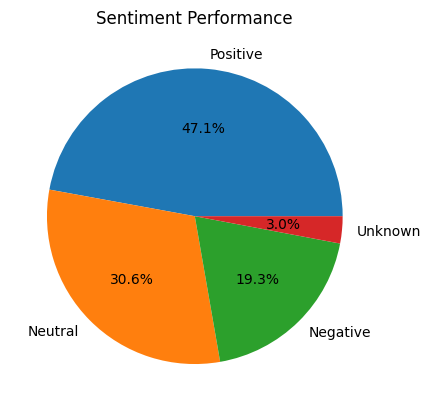

In [75]:
#Which sentiment performs best
plt.pie(df['sentiment'].value_counts(), labels=df['sentiment'].value_counts().index, autopct='%1.1f%%')
plt.title('Sentiment Performance')
plt.show()
# From the below pie chart Positive sentiment analysis has good numbers of 47% where neutral or mixed opinion places 30% amd negative has 19.3%
